# Calculate stretch ratio of lattice plane spacings
* Contributor: Martin Diehl (https://martin-diehl.net), Philip Eisenlohr ([pe@msu.edu](mailto:pe@msu.edu))
* DAMASK version: 3.1.0
* Prerequisites (data): DADF5 file with deformation gradient ('F'), elastic deformation gradient ('F_e'), and crystallographic orientation ('O')

In [1]:
%matplotlib inline

In [2]:
from collections import defaultdict

import damask
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True # set to False if Latex is not installed

## Procedure for lattice stretch calculation

Since "lattice strains" (actually the stretch of lattice plane spacings) are frequently measured by X-ray diffraction techniques, we adopt the notion that only grains for which a given $\{hkl\}$ plane is perpendicular (within a tolerance) to a selected reflection direction $\mathbf{q}$ will contribute to the signal.

For those orientations, the reciprocal stretch ratio $\lambda_{hkl}^{-1}$ of the $\{hkl\}$ reciprocal plane spacing can be calculated as

$$
\lambda_{hkl}^{-1} = \left|\left|\mathbf{V}_\text{e}^{-1}\,\mathbf{n}_{hkl}\right|\right|,
$$

where $\mathbf{V}_\text{e}$ is the left elastic stretch tensor that acts in the lab frame (following from $\mathbf{F}_\text{e} = \mathbf{V}_\text{e} \mathbf{R}_\text{cystal}^\text{lab}$) and $\mathbf{n}_{hkl}$ is a unit vector along the $\{hkl\}$ plane normal expressed in the lab coordinate frame.

### Explanation


Let $\mathbf{d}_{hkl}$ be a vector in the lattice frame that is normal to the lattice plane $\{hkl\}$ and has magnitude of the reciprocal of the plane spacing.
This vector has components $(h,k,l)$ in the dual basis $\mathbf{e}_j$ of the lattice.
Then, $\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl}$, which is parallel to $\mathbf{q}$, constitutes the same vector but expressed not in the crystal frame but in the lab frame.
That plane normal gets transformed by the action of the elastic stretch $\mathbf{V}_\text{e}$ to $\mathbf{V}_\text{e}^{-\text T}\,\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl} \equiv \mathbf{V}_\text{e}^{-1}\,\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl}$.
Lastly, the ratio of the reciprocal plane spacings follows as
$\left|\left|\mathbf{V}_\text{e}^{-1}\,\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl}\right|\right| \big/ \left|\left|\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl}\right|\right|$, which can be simplified to the above expression with $\mathbf{n}_{hkl} = \mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl} \big/ \left|\left|\mathbf{R}_\text{crystal}^\text{lab}\,\mathbf{d}_{hkl}\right|\right|$.


### Transformation of dual basis

Let the lattice basis vectors $\mathbf{e}_j$ be transformed by the linear map $\mathbf{M}$ such that

$$
\mathbf{e}^\prime_j = \mathbf{M}\,\mathbf{e}_j.
$$

This entails the dual basis transforming by the inverse transpose of $\mathbf{M}$ to

$$
\mathbf{e}^{\prime\,i} = \mathbf{M}^{-\text{T}}\,\mathbf{e}^{i}
$$

because both transformed bases still maintain biorthogonality, i.e.,

$$
\mathbf{e}^{\prime\,i} \cdot \mathbf{e}^{\prime}_j =
\mathbf{M}^{-\text{T}}\,\mathbf{e}^{i} \cdot \mathbf{M}\,\mathbf{e}_j =
\mathbf{e}^{i}\,\mathbf{M}^{-1} \mathbf{M}\,\mathbf{e}_{j} =
\mathbf{e}^{i} \cdot \mathbf{e}_{j} =
\delta^i_j.
$$

Therefore, the dual basis transforms as
- $\mathbf{e}^{\prime\,i} = \mathbf{R}\,\mathbf{e}^i$ if $\mathbf{M}$ is a pure rotation $\mathbf{R} = \mathbf{R}^{-\text{T}}$
- $\mathbf{e}^{\prime\,i} = \mathbf{V}^{-1}\,\mathbf{e}^i$ if $\mathbf{M}$ is a pure stretch $\mathbf{V} = \mathbf{V}^\text T$


In [3]:
def plane_stretch_ratios(F_e,O,hkl,n,tolerance=0,degrees=False):
    """
    Calculate stretch ratio of {hkl} planes that are perpendicular to lab direction n from elastic deformation gradient F_e.
    
    Parameters
    ----------
    F_e : numpy.ndarray, shape (...,3,3)
        Elastic deformation gradient for each orientation.
    O : damask.Orientation, shape (...)
        Orientations.
    hkl : numpy.ndarray, shape (3)
        Miller indices of plane normal.
    n : numpy.ndarray, shape (3)
        Normal direction in lab frame to select valid orientations having {hkl} aligned with n.
    tolerance : float, optional
        Maximum deviation angle between lattice plane normal {hkl} and lab normal direction n.
        Defaults to 0.
    degrees : bool, optional
        Tolerance is given in degrees.
        Defaults to False.
    
    Returns
    -------
    ratios : numpy.ndarray (float)
        Stretch ratios of all (symmetrically equivalent) {hkl} planes.
    """
    hkls = O.to_frame(hkl=hkl,with_symmetry=True,normalize=True)
    aligned = np.abs(np.einsum('...i,i',hkls,n/np.linalg.norm(n))) > np.cos(np.radians(tolerance) if degrees else tolerance)
    return 1./np.linalg.norm(
        np.einsum('...ij,...j',
                  np.linalg.inv(damask.mechanics.stretch_left(np.broadcast_to(F_e,O.symmetry_operations.shape+F_e.shape)[aligned])),
                  hkls[aligned],
                 ),
        axis=-1)


## Selection of diffraction normal and {hkl} planes

The load case used in this example does unidirectionally extend the sample along $x$. Hence, interesting directions to interrogate the resulting lattice strains would be along $x$, $y$, or $z$.

The expectation is that lattice plane spacings are generally stretched when measured along $x$, whereas they should be compressed when observed perpendicular to $x$, i.e., along $y$ or $z$.

Three different lattice planes are selected to examine the influence of directional stiffness and strength of the investigated material, here face-centered cubic Al. For Al, the stiffness is highest along $\langle 1 1 1 \rangle$ and lowest along $\langle 1 0 0 \rangle$. Hence, one would expect the lattice plane spacings to be stretched most for $\{ 1 0 0 \}$ and least for $\{ 1 1 1 \}$ planes. However, the strength of face-centered cubic lattices is also highest along $\langle 1 1 1 \rangle$, such that grains oriented as such are prone to attain high stress, which stretches the $\{1 1 1\}$ spacings relatively more compared to (progressively softer) $\langle 1 1 0 \rangle$ and $\langle 1 0 0 \rangle$ orientations than a purely elastic consideration suggests.

In [4]:
direction = np.array([1,0,0])   # direction used for lattice plane stretch measurement (Bragg reflection normal) in lab coordinates.
threshold = 5                   # allowed misalignment in degree

hkls = [[1,0,0],
        [1,1,0],
        [1,1,1]]                # lattice planes to consider


In [5]:
fname = 'lattice_strain/simple_tensionX_material.hdf5'
r = damask.Result(fname)


In [6]:
strain = []
stretch = defaultdict(list)

for i in r.increments:
    view = r.view(increments=i)
    
    strain.append(damask.mechanics.equivalent_strain_Mises(
        damask.mechanics.strain(np.average(view.get('F'),axis=0),t='U',m=0.0)
    ))

    F_e = view.get('F_e')
    O_ = view.get('O')
    O = damask.Orientation(O_,lattice=O_.dtype.metadata['lattice'])

    for hkl in hkls:
        stretch[str(hkl)].append(
            np.average(
                plane_stretch_ratios(
                    F_e=F_e,
                    O=O,
                    hkl=hkl,
                    n=direction,
                    tolerance=threshold,
                    degrees=True)
            )
        )

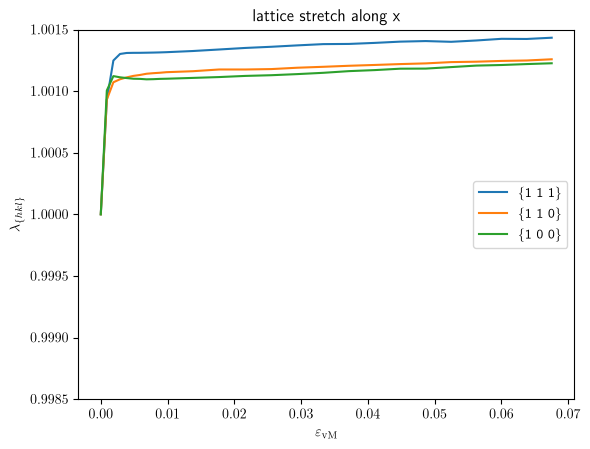

In [7]:
fig, ax = plt.subplots()
for hkl in sorted(hkls, key=lambda hkl: stretch[str(hkl)][-1],reverse=True):
    ax.plot(strain,
            stretch[str(hkl)],
            label=('\\{{{} {} {}\\}}' if plt.rcParams['text.usetex'] else '{{{} {} {}}}').format(*hkl))
    
ax.set_title('lattice stretch along '+'+'.join([f'{a if a!=1 else ""}{d}' for d,a in zip('xyz',direction) if a>0]))
ax.set_xlabel(r'$\varepsilon_\mathrm{vM}$')
ax.set_ylabel(r'$\lambda_{\{hkl\}}$')
ax.set_ylim(0.9985,1.0015)
ax.legend(loc='center right')

plt.show()